In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns

In [133]:
#dataset given in the mail
dataset = pd.read_csv('Information (2).csv', encoding = 'latin-1')

In [135]:
dataset.head()

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,gender,gender:confidence,profile_yn,profile_yn:confidence,created,...,profileimage,retweet_count,sidebar_color,text,tweet_coord,tweet_count,tweet_created,tweet_id,tweet_location,user_timezone
0,815719226,False,finalized,3,10/26/15 23:24,male,1.0000,yes,1.0,12/5/13 1:48,...,https://pbs.twimg.com/profile_images/414342229...,0,FFFFFF,Robbie E Responds To Critics After Win Against...,NaN,110964,10/26/15 12:40,6.587300e+17,main; @Kan1shk3,Chennai
1,815719227,False,finalized,3,10/26/15 23:30,male,1.0000,yes,1.0,10/1/12 13:51,...,https://pbs.twimg.com/profile_images/539604221...,0,C0DEED,ÛÏIt felt like they were my friends and I was...,NaN,7471,10/26/15 12:40,6.587300e+17,NaN,Eastern Time (US & Canada)
2,815719228,False,finalized,3,10/26/15 23:33,male,0.6625,yes,1.0,11/28/14 11:30,...,https://pbs.twimg.com/profile_images/657330418...,1,C0DEED,i absolutely adore when louis starts the songs...,NaN,5617,10/26/15 12:40,6.587300e+17,clcncl,Belgrade
3,815719229,False,finalized,3,10/26/15 23:10,male,1.0000,yes,1.0,6/11/09 22:39,...,https://pbs.twimg.com/profile_images/259703936...,0,C0DEED,Hi @JordanSpieth - Looking at the url - do you...,NaN,1693,10/26/15 12:40,6.587300e+17,"Palo Alto, CA",Pacific Time (US & Canada)
4,815719230,False,finalized,3,10/27/15 1:15,female,1.0000,yes,1.0,4/16/14 13:23,...,https://pbs.twimg.com/profile_images/564094871...,0,0,Watching Neighbours on Sky+ catching up with t...,NaN,31462,10/26/15 12:40,6.587300e+17,NaN,NaN


In [137]:
dataset['gender'].unique()

array(['male', 'female', 'brand', 'unknown', nan], dtype=object)

In [139]:
dataset.shape

(20050, 26)

In [141]:
dataset.isnull().sum()

_unit_id                     0
_golden                      0
_unit_state                  0
_trusted_judgments           0
_last_judgment_at           50
gender                      97
gender:confidence           26
profile_yn                   0
profile_yn:confidence        0
created                      0
description               3744
fav_number                   0
gender_gold              20000
link_color                   0
name                         0
profile_yn_gold          20000
profileimage                 0
retweet_count                0
sidebar_color                0
text                         0
tweet_coord              19891
tweet_count                  0
tweet_created                0
tweet_id                     0
tweet_location            7485
user_timezone             7798
dtype: int64

In [143]:
dataset['gender'].value_counts()

gender
female     6700
male       6194
brand      5942
unknown    1117
Name: count, dtype: int64

## Feature Selection

In [146]:
dataset.drop(['_unit_id', 'created', 'name', 'profileimage', 'gender_gold', 'profile_yn_gold',
             'user_timezone', 'tweet_location', 'tweet_id', '_last_judgment_at', 'fav_number',
             'tweet_coord', '_golden', '_unit_state', '_trusted_judgments', 'profile_yn',
             'profile_yn:confidence', 'gender_gold', 'link_color', 'profile_yn_gold',
             'sidebar_color', 'tweet_created'], axis = 1, inplace = True)

In [148]:
dataset.dropna(inplace = True)

In [150]:
dataset.shape

(16224, 6)

## Data Visualisation

Text(0.5, 1.0, 'Number of Records for each Category')

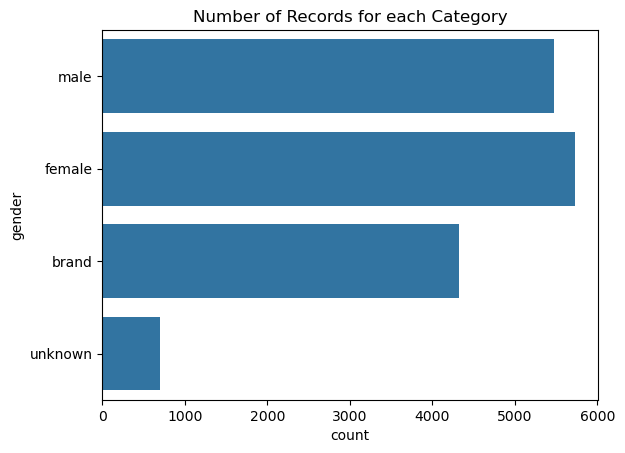

In [153]:
#plot of number of records for each category
sns.countplot(dataset['gender'],label="Gender")
plt.title('Number of Records for each Category')

In [155]:
dataset = dataset[dataset['gender'] != 'unknown']

Text(0.5, 1.0, 'Tweet Counts for each Category')

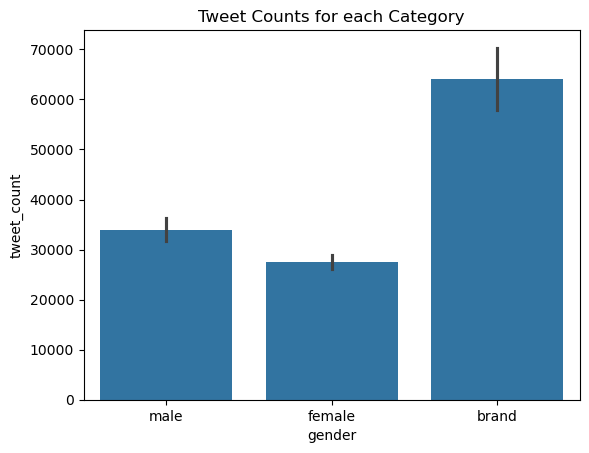

In [157]:
#number of tweets according to the categories
sns.barplot(x = 'gender', y = 'tweet_count', data = dataset)
plt.title('Tweet Counts for each Category')

Text(0.5, 1.0, 'Re-tweet count for each Category')

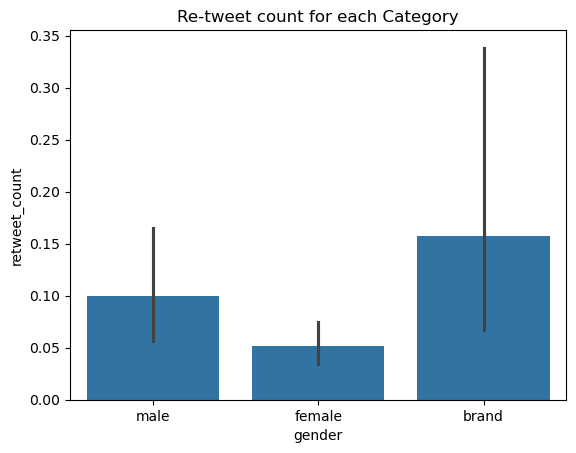

In [158]:
#number of re-tweets according to categories
sns.barplot(x = 'gender', y = 'retweet_count', data = dataset)
plt.title('Re-tweet count for each Category')

## Tags and Hyperlinks

In [161]:
males_df = dataset[dataset['gender'] == 'male']
females_df = dataset[dataset['gender'] == 'female']
brands_df = dataset[dataset['gender'] == 'brand']

In [164]:
male_tags_count, females_tags_count, brands_tags_count = 0, 0, 0
for x in males_df['text']:
    if '#' in x:
        male_tags_count += x.count('#')
for x in females_df['text']:
    if '#' in x:
        females_tags_count += x.count('#')
for x in brands_df['text']:
    if '#' in x:
        brands_tags_count += x.count('#')

In [166]:
gender_tags = {'male': male_tags_count, 'female': females_tags_count, 'brand': brands_tags_count}
keys = gender_tags.keys()
values = gender_tags.values()

Text(0.5, 1.0, 'Number of Tags used by each Category')

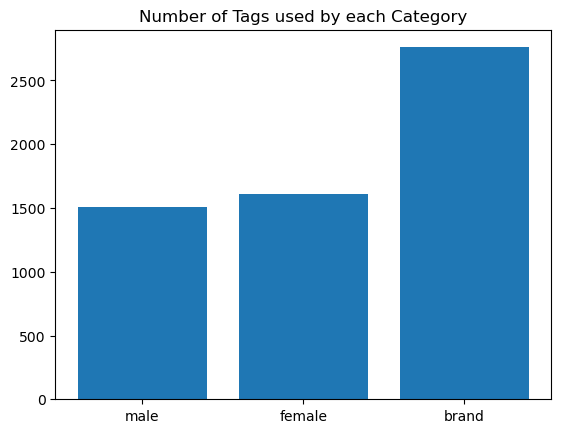

In [168]:
#plot of category vs no.of tags used
plt.bar(keys, values)
plt.title('Number of Tags used by each Category')

## Removing all Punctuations along with hyperlinks, tags, @names

In [188]:
def clean_text(s):
    not_req = ['@', '#', '://']
    s = str(s)
    s = s.lower()
    s = re.sub(r'\\d+', '', s)
    s = re.sub(r'http\S+|www\.\S+', '', s)            # remove URLs
    s = re.sub(r'[^\w\s]', '', s)                     # remove punctuation
    lst = s.split(' ')
    lst1 = []
    for x in lst:
        for el in not_req:
            if el in x:
                lst1.append(x)
    for i in lst1:
        try:
            lst.remove(i)
        except ValueError:
            pass
    final_str = " ".join(lst)
    final_str = re.sub(r'[^\w\s]', '', final_str)

    return final_str

In [190]:
dataset['text'] = dataset['text'].apply(clean_text)
dataset['description'] = dataset['description'].apply(clean_text)

In [194]:
dataset.head()

,gender,gender:confidence,description,retweet_count,text,tweet_count,text_temp,description_temp
0,male,1.0000,i sing my own rhythm,0,robbie e responds to critics after win against...,110964,robbie e responds to critics after win against...,i sing my own rhythm
1,male,1.0000,im the author of novels filled with family dra...,0,ûïit felt like they were my friends and i was ...,7471,ûïit felt like they were my friends and i was ...,im the author of novels filled with family dra...
2,male,0.6625,louis whining and squealing and all,1,i absolutely adore when louis starts the songs...,5617,i absolutely adore when louis starts the songs...,louis whining and squealing and all
3,male,1.0000,mobile guy 49ers shazam google kleiner perkin...,0,hi jordanspieth looking at the url do you us...,1693,hi jordanspieth looking at the url do you us...,mobile guy 49ers shazam google kleiner perkin...
4,female,1.0000,ricky wilson the best frontmankaiser chiefs th...,0,watching neighbours on sky catching up with th...,31462,watching neighbours on sky catching up with th...,ricky wilson the best frontmankaiser chiefs th...


## Natural Language Processing

In [25]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   

True

In [26]:
from nltk.corpus import stopwords

In [28]:
list_of_stopwords = stopwords.words('English')

In [200]:
#function for tokenizing the words
def tokenization(text):
    text = re.split('\W+', text)
    return text

dataset['text_tokenized'] = dataset['text'].apply(lambda x: tokenization(x.lower()))
dataset['descp_tokenized'] = dataset['description'].apply(lambda x: tokenization(x.lower()))

In [202]:
#function for removing stopwords
def remove_stopwords(text):
    text = [word for word in text if word not in list_of_stopwords]
    return text
    
dataset['text_tokenized'] = dataset['text_tokenized'].apply(lambda x: remove_stopwords(x))
dataset['descp_tokenized'] = dataset['descp_tokenized'].apply(lambda x: remove_stopwords(x))
dataset.head()

,gender,gender:confidence,description,retweet_count,text,tweet_count,text_tokenized,descp_tokenized
0,male,1.0000,i sing my own rhythm,0,robbie e responds to critics after win against...,110964,"[robbie, e, responds, critics, win, eddie, edw...","[sing, rhythm]"
1,male,1.0000,im the author of novels filled with family dra...,0,ûïit felt like they were my friends and i was ...,7471,"[ûïit, felt, like, friends, living, story, the...","[im, author, novels, filled, family, drama, ro..."
2,male,0.6625,louis whining and squealing and all,1,i absolutely adore when louis starts the songs...,5617,"[absolutely, adore, louis, starts, songs, hits...","[louis, whining, squealing]"
3,male,1.0000,mobile guy 49ers shazam google kleiner perkin...,0,hi jordanspieth looking at the url do you us...,1693,"[hi, jordanspieth, looking, url, use, ifttt, d...","[mobile, guy, 49ers, shazam, google, kleiner, ..."
4,female,1.0000,ricky wilson the best frontmankaiser chiefs th...,0,watching neighbours on sky catching up with th...,31462,"[watching, neighbours, sky, catching, neighbs,...","[ricky, wilson, best, frontmankaiser, chiefs, ..."


In [206]:
ps = nltk.PorterStemmer()

def stemming(text):
    text = [ps.stem(word) for word in text]
    return text

dataset['text_stemmed'] = dataset['text_tokenized'].apply(lambda x: stemming(x))
dataset['descp_stemmed'] = dataset['descp_tokenized'].apply(lambda x: stemming(x))
dataset.head()

,gender,gender:confidence,description,retweet_count,text,tweet_count,text_tokenized,descp_tokenized,text_stemmed,descp_stemmed
0,male,1.0000,i sing my own rhythm,0,robbie e responds to critics after win against...,110964,"[robbie, e, responds, critics, win, eddie, edw...","[sing, rhythm]","[robbi, e, respond, critic, win, eddi, edward,...","[sing, rhythm]"
1,male,1.0000,im the author of novels filled with family dra...,0,ûïit felt like they were my friends and i was ...,7471,"[ûïit, felt, like, friends, living, story, the...","[im, author, novels, filled, family, drama, ro...","[ûïit, felt, like, friend, live, stori, themû,...","[im, author, novel, fill, famili, drama, romanc]"
2,male,0.6625,louis whining and squealing and all,1,i absolutely adore when louis starts the songs...,5617,"[absolutely, adore, louis, starts, songs, hits...","[louis, whining, squealing]","[absolut, ador, loui, start, song, hit, hard, ...","[loui, whine, squeal]"
3,male,1.0000,mobile guy 49ers shazam google kleiner perkin...,0,hi jordanspieth looking at the url do you us...,1693,"[hi, jordanspieth, looking, url, use, ifttt, d...","[mobile, guy, 49ers, shazam, google, kleiner, ...","[hi, jordanspieth, look, url, use, ifttt, dont...","[mobil, guy, 49er, shazam, googl, kleiner, per..."
4,female,1.0000,ricky wilson the best frontmankaiser chiefs th...,0,watching neighbours on sky catching up with th...,31462,"[watching, neighbours, sky, catching, neighbs,...","[ricky, wilson, best, frontmankaiser, chiefs, ...","[watch, neighbour, sky, catch, neighb, xxx, _ù...","[ricki, wilson, best, frontmankais, chief, bes..."


In [208]:
#combining all the words for creating the bag of words
dataset['list_of_all_words'] = dataset['text_stemmed'] + dataset['descp_stemmed']

In [210]:
#joining the words to sentences
dataset['final_sentences'] = [' '.join(x) for x in dataset['list_of_all_words']]

### Maximum Used Words according to the Categories

In [224]:
male_text = ' '.join(dataset[dataset['gender'] == 'male']['final_sentences'])
female_text = ' '.join(dataset[dataset['gender'] == 'female']['final_sentences'])
brand_text = ' '.join(dataset[dataset['gender'] == 'brand']['final_sentences'])

In [226]:
from wordcloud import WordCloud

#### Male

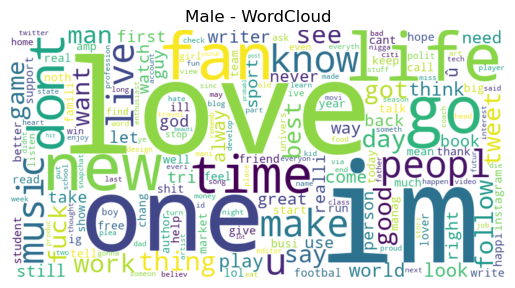

In [230]:
# Male
wordcloud_male = WordCloud(width=800, height=400, background_color='white').generate(male_text)
plt.imshow(wordcloud_male, interpolation='bilinear')
plt.axis('off')
plt.title('Male - WordCloud')
plt.show()

#### Female

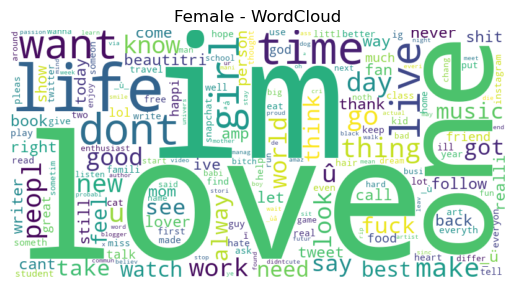

In [236]:
wordcloud_female = WordCloud(width=800, height=400, background_color='white').generate(female_text)
plt.imshow(wordcloud_female, interpolation='bilinear')
plt.axis('off')
plt.title('Female - WordCloud')
plt.show()

#### Brand

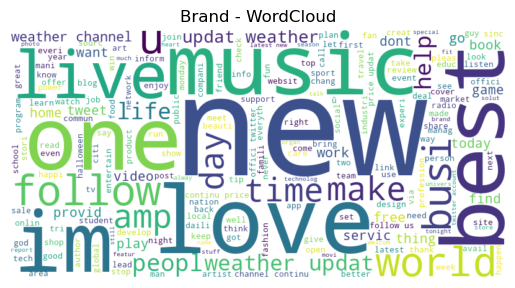

In [234]:
wordcloud_brand = WordCloud(width=800, height=400, background_color='white').generate(brand_text)
plt.imshow(wordcloud_brand, interpolation='bilinear')
plt.axis('off')
plt.title('Brand - WordCloud')
plt.show()

## TF_IDF

In [239]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [241]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=9000)
X_text = tfidf.fit_transform(dataset['final_sentences']).toarray()

## Numeric Features

In [248]:
from sklearn.preprocessing import StandardScaler
X_num = dataset[['gender:confidence', 'tweet_count', 'retweet_count']].values
scaler = StandardScaler()
X_num = scaler.fit_transform(X_num)

In [ ]:
# Rewrite and summarize the improved pipeline with TF-IDF, better model, and cleaned target classes
improved_pipeline_code = '''

# Numeric features
X_num = dataset[['gender:confidence', 'tweet_count', 'retweet_count']].values
scaler = StandardScaler()
X_num = scaler.fit_transform(X_num)

# Combine features
X = np.concatenate((X_text, X_num), axis=1)

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(dataset['gender'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Train logistic regression
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Improved Logistic Regression Accuracy: {accuracy * 100:.2f}%")
'''

# Display code to user
improved_pipeline_code


## Array for Independent and Dependent Variables

In [250]:
# concatenating both numpy arrays to make the final data omn independent variables
X = np.concatenate((X_text, X_num), axis=1)

In [251]:
X.shape

(15522, 9003)

In [254]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(dataset['gender'])

## Splitting dataset to Training and Testing

In [256]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

# Classification

## Gaussian NB

In [258]:
from sklearn.linear_model import LogisticRegression

In [260]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [262]:
y_pred = model.predict(X_test)

In [264]:
from sklearn.metrics import accuracy_score

In [266]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")

Improved Logistic Regression Accuracy: 62.08%


## RandomForest Classifier

In [268]:
from sklearn.ensemble import RandomForestClassifier

In [276]:
rfc = RandomForestClassifier(n_estimators=100, random_state = 0)
rfc.fit(X_train,y_train)

RandomForestClassifier(random_state=0)

In [278]:
y_pred_rfc = rfc.predict(X_test)

In [280]:
print("Random Forest: ", accuracy_score(y_pred_rfc, y_test )*100)

Random Forest:  59.394459952759284


In [284]:
from sklearn.model_selection import GridSearchCV

In [286]:
rf = RandomForestClassifier()
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(rf, param_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
print("Best Random Forest Params:", grid_rf.best_params_)
print("Test Accuracy:", grid_rf.score(X_test, y_test))
print(classification_report(y_test, grid_rf.predict(X_test), target_names=le.classes_))

KeyboardInterrupt: 

## XGBoost

In [72]:
from xgboost import XGBClassifier

In [73]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
print("XGBoost", accuracy_score(y_pred_xgb, y_test )*100)